# Comment Divergence Analysis

This notebook compares comment patterns between six groups:

- Female Neutral
- Female ProChoice
- Female ProLife
- Male Neutral
- Male ProChoice
- Male ProLife

The first **N comments** from each file are compared using two divergence measures.

---

## 1.Divergence 

**Formula:**

$$
(A,B)=\frac{|A\triangle B|}{|A|+|B|}
$$

Measures the difference in comment content while ignoring order.  
It treats comments as multisets and preserves duplicates.

- 0 : identical comment content
- 1: completely different comment content
---
## 2. Ordered Sequence Divergence (Comment Order)

**Formula:**

$$D_{\text{order}}(A,B) = \frac{1}{n} \sum_{i=1}^{n} \mathbb{I}(A_{j,i} \neq B_{j,i})$$

Measures differences in comment order by comparing comments position-by-position across all files.

- **0**: identical sequence
- **1**: completely different sequence


First 5 Comments Divergence 

                  Female Neutral  Female ProChoice  Female ProLife  \
Female Neutral             0.000             0.133           0.129   
Female ProChoice           0.133             0.000           0.099   
Female ProLife             0.129             0.099           0.000   
Male Neutral               0.208             0.207           0.208   
Male ProChoice             0.196             0.202           0.199   
Male ProLife               0.184             0.201           0.192   

                  Male Neutral  Male ProChoice  Male ProLife  
Female Neutral           0.208           0.196         0.184  
Female ProChoice         0.207           0.202         0.201  
Female ProLife           0.208           0.199         0.192  
Male Neutral             0.000           0.201         0.219  
Male ProChoice           0.201           0.000         0.236  
Male ProLife             0.219           0.236         0.000  

First 5 Comments Divergence by Order

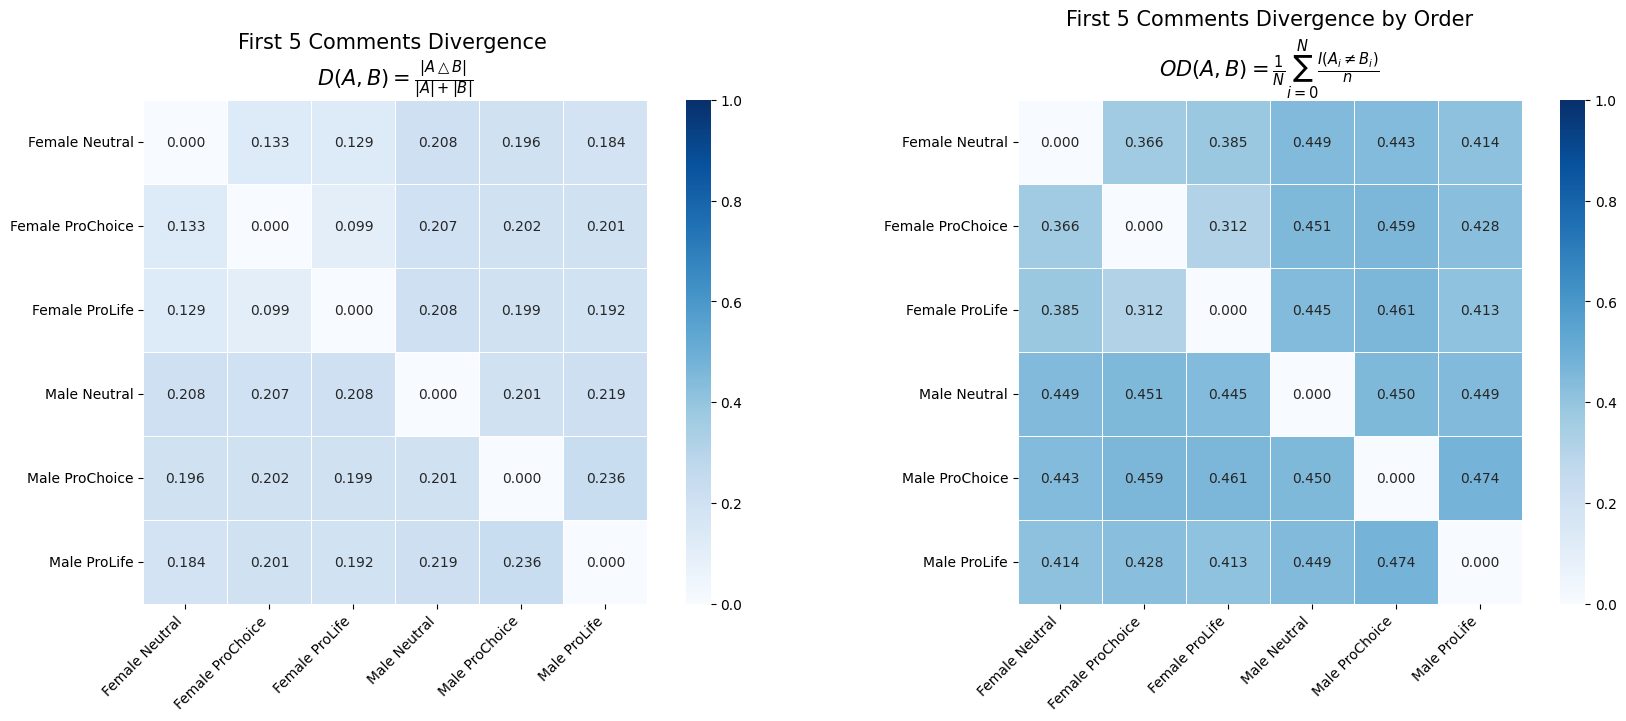

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


# ==========================================================
# Dataset location
# ==========================================================

base_path = "/Users/shergoshami/Downloads/DATA"


folders = {
    "Female Neutral": "female_neutral",
    "Female ProChoice": "female_prochoice",
    "Female ProLife": "female_prolife",
    "Male Neutral": "male_neutral",
    "Male ProChoice": "male_prochoice",
    "Male ProLife": "male_prolife"
}


# ==========================================================

# Number of Top N Comments 
# ==========================================================

N = 5



# ==========================================================
# Load dataset
# Store:
# group_files[group][filename] = [(username, comment), ...]
# ==========================================================

group_files = {}


for group, folder in folders.items():

    folder_path = os.path.join(
        base_path,
        folder
    )


    if not os.path.exists(folder_path):

        print(
            f"Missing folder: {folder_path}"
        )

        continue



    group_files[group] = {}



    for file in sorted(os.listdir(folder_path)):


        if not file.endswith(".json"):

            continue



        file_path = os.path.join(
            folder_path,
            file
        )


        with open(
            file_path,
            "r",
            encoding="utf-8"
        ) as f:

            data = json.load(f)



        comments = []


        for comment in data.get(
            "comments",
            []
        ):


            text = comment.get(
                "comment",
                ""
            )


            # Normalize GIFs
            if text.startswith("[GIF:"):

                text = "[GIF]"



            signature = (
                comment.get(
                    "username",
                    ""
                ).strip(),
                text
            )


            # Keep duplicates
            comments.append(signature)



        group_files[group][file] = comments





# ==========================================================
# Select first N comments
# ==========================================================

def first_n(A, B, N):

    return (
        A[:N],
        B[:N]
    )





# ==========================================================
# 1. Multiset Symmetric Difference Divergence
# ==========================================================

def divergence_formula(A, B):

    counter_A = Counter(A)

    counter_B = Counter(B)



    difference = (
        counter_A - counter_B
    ) + (
        counter_B - counter_A
    )



    numerator = sum(
        difference.values()
    )


    denominator = (
        len(A) + len(B)
    )


    if denominator == 0:

        return 0


    return numerator / denominator





# ==========================================================
# Create Multiset Divergence Matrix
# ==========================================================

def multiset_divergence_matrix(
        group_files,
        N
):

    groups = list(
        group_files.keys()
    )


    matrix = []



    for g1 in groups:


        row = []



        for g2 in groups:



            if g1 == g2:

                row.append(0)

                continue



            files_A = group_files[g1]

            files_B = group_files[g2]



            common_files = (
                set(files_A.keys())
                &
                set(files_B.keys())
            )


            values = []



            for filename in sorted(common_files):


                A, B = first_n(
                    files_A[filename],
                    files_B[filename],
                    N
                )


                values.append(
                    divergence_formula(
                        A,
                        B
                    )
                )



            if values:

                row.append(
                    sum(values) / len(values)
                )

            else:

                row.append(0)



        matrix.append(row)



    return pd.DataFrame(
        matrix,
        index=groups,
        columns=groups
    )





# ==========================================================
# 2. Ordered Divergence
# ==========================================================

def order_divergence(A, B):

    n = min(
        len(A),
        len(B)
    )


    if n == 0:

        return 0



    difference = 0



    for i in range(n):

        if A[i] != B[i]:

            difference += 1



    return difference / n





# ==========================================================
# Create Ordered Divergence Matrix
# ==========================================================

def ordered_divergence_matrix(
        group_files,
        N
):

    groups = list(
        group_files.keys()
    )


    matrix = []



    for g1 in groups:


        row = []



        for g2 in groups:



            if g1 == g2:

                row.append(0)

                continue



            files_A = group_files[g1]

            files_B = group_files[g2]



            common_files = (
                set(files_A.keys())
                &
                set(files_B.keys())
            )



            values = []



            for filename in sorted(common_files):


                A, B = first_n(
                    files_A[filename],
                    files_B[filename],
                    N
                )


                values.append(
                    order_divergence(
                        A,
                        B
                    )
                )



            if values:

                row.append(
                    sum(values) / len(values)
                )

            else:

                row.append(0)



        matrix.append(row)



    return pd.DataFrame(
        matrix,
        index=groups,
        columns=groups
    )





# ==========================================================
# Generate matrices
# ==========================================================

df_multiset = multiset_divergence_matrix(
    group_files,
    N
)


df_ordered = ordered_divergence_matrix(
    group_files,
    N
)





# ==========================================================
# Print results
# ==========================================================

print("\n====================================")
print(f"First {N} Comments Divergence \n")
print("====================================")

print(
    df_multiset.round(3)
)



print("\n====================================")
print(f"First {N} Comments Divergence by Order\n")
print("====================================")

print(
    df_ordered.round(3)
)





# ==========================================================
# Plot both heatmaps side by side
# ==========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7)
)


# ------------------------------
# Divergence heatmap
# ------------------------------

sns.heatmap(
    df_multiset,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5,
    square=True,
    vmin=0,
    vmax=1,
    ax=axes[0]
)


axes[0].set_title(
    f"First {N} Comments Divergence \n"
    r"$D(A,B)=\frac{|A\triangle B|}{|A|+|B|}$",
    fontsize=15
)


axes[0].set_xticklabels(
    axes[0].get_xticklabels(),
    rotation=45,
    ha="right"
)

axes[0].set_yticklabels(
    axes[0].get_yticklabels(),
    rotation=0
)



# ------------------------------
# Ordered divergence heatmap
# ------------------------------

sns.heatmap(
    df_ordered,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    linewidths=0.5,
    square=True,
    vmin=0,
    vmax=1,
    ax=axes[1]
)

axes[1].set_title(
    f"First {N} Comments Divergence by Order\n"
    r"$OD(A,B)=\frac{1}{N}\sum_{i=0}^{N} \frac{I(A_i \neq B_i)}{n}$",
    fontsize=15
)
axes[1].set_xticklabels(
    axes[1].get_xticklabels(),
    rotation=45,
    ha="right"
)

axes[1].set_yticklabels(
    axes[1].get_yticklabels(),
    rotation=0
)



plt.tight_layout()

plt.show()

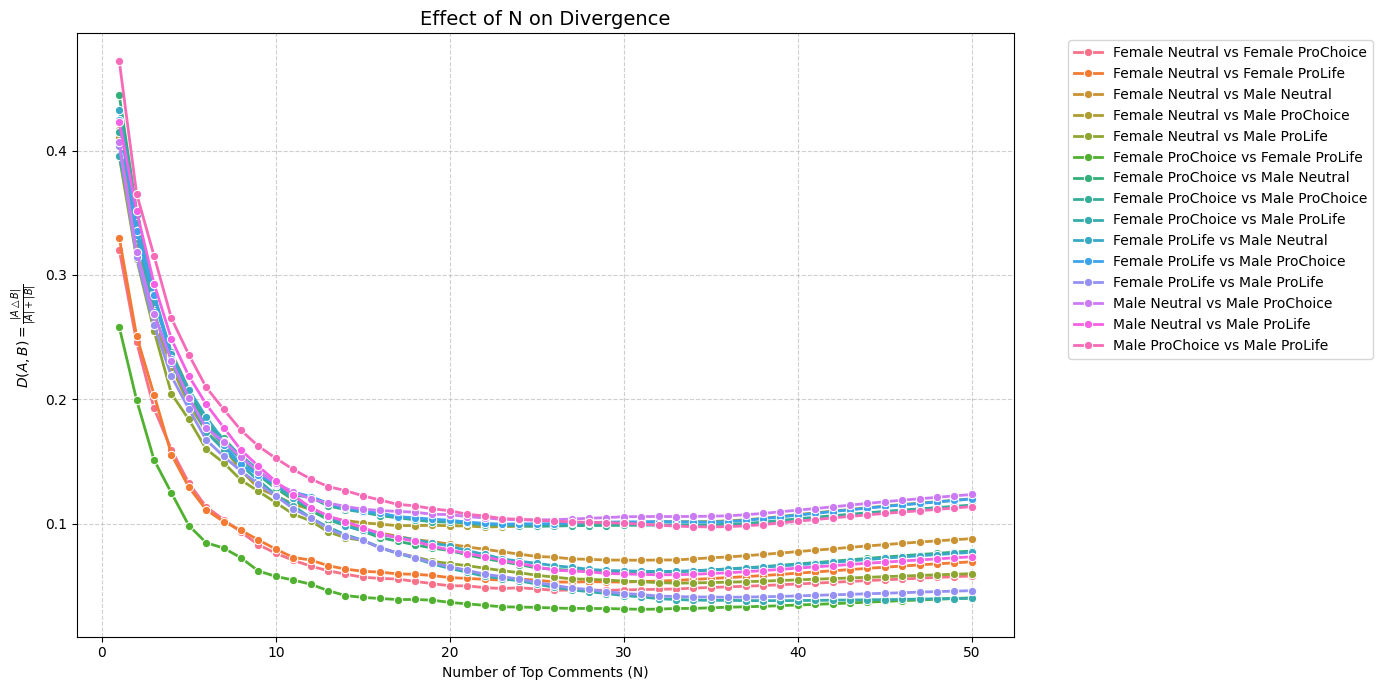

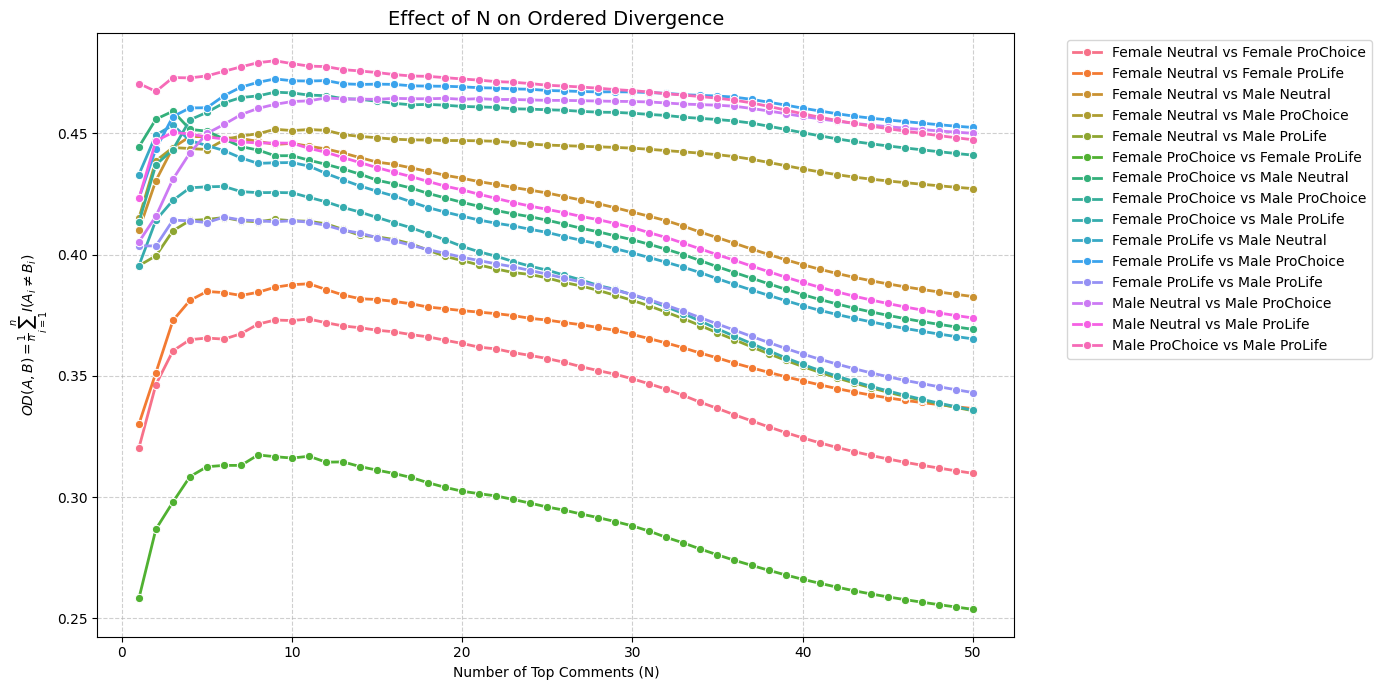

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# ==========================================================
# Compute both divergences as function of N
# ==========================================================

def divergence_by_n(group_files, max_n=50):

    groups = list(group_files.keys())

    results = []


    for n in range(1, max_n + 1):

        for i, g1 in enumerate(groups):

            for g2 in groups[i+1:]:


                files_A = group_files[g1]

                files_B = group_files[g2]


                # Same files only
                common_files = (
                    set(files_A.keys())
                    &
                    set(files_B.keys())
                )


                multiset_values = []

                ordered_values = []



                for filename in sorted(common_files):


                    # First N comments
                    A = files_A[filename][:n]

                    B = files_B[filename][:n]



                    # -----------------------------
                    # Multiset divergence
                    # -----------------------------

                    d_multi = divergence_formula(
                        A,
                        B
                    )


                    multiset_values.append(
                        d_multi
                    )



                    # -----------------------------
                    # Ordered divergence
                    # -----------------------------

                    d_order = order_divergence(
                        A,
                        B
                    )


                    ordered_values.append(
                        d_order
                    )



                if common_files:


                    results.append({

                        "n": n,

                        "Pair": f"{g1} vs {g2}",

                        "Group A": g1,

                        "Group B": g2,

                        "Multiset Divergence":
                            sum(multiset_values)
                            /
                            len(multiset_values),


                        "Ordered Divergence":
                            sum(ordered_values)
                            /
                            len(ordered_values)

                    })


    return pd.DataFrame(results)



# ==========================================================
# Run
# ==========================================================

df_n_trajectory = divergence_by_n(
    group_files,
    max_n=50
)



# ==========================================================
# Plot Divergence
# ==========================================================

plt.figure(
    figsize=(14,7)
)


sns.lineplot(
    data=df_n_trajectory,
    x="n",
    y="Multiset Divergence",
    hue="Pair",
    marker="o",
    linewidth=2
)


plt.title(
    "Effect of N on Divergence",
    fontsize=14
)

plt.xlabel(
    "Number of Top Comments (N)"
)

plt.ylabel(
    r"$D(A,B)=\frac{|A\triangle B|}{|A|+|B|}$"
)


plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.6
)

plt.tight_layout()

plt.show()



# ==========================================================
# Plot Ordered Divergence
# ==========================================================

plt.figure(
    figsize=(14,7)
)


sns.lineplot(
    data=df_n_trajectory,
    x="n",
    y="Ordered Divergence",
    hue="Pair",
    marker="o",
    linewidth=2
)


plt.title(
    "Effect of N on Ordered Divergence",
    fontsize=14
)


plt.xlabel(
    "Number of Top Comments (N)"
)


plt.ylabel(
    r"$OD(A,B)=\frac{1}{n}\sum_{i=1}^{n}I(A_i\neq B_i)$"
)


plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)


plt.grid(
    True,
    linestyle="--",
    alpha=0.6
)


plt.tight_layout()

plt.show()